**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# Will help to load the dataset
from datasets import load_dataset

**Load Dataset**

In [2]:
emotion_dataset = load_dataset("dair-ai/emotion")
train_text =  emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [3]:
label_names = emotion_dataset['train'].features['label'].names

In [4]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [6]:
print(df_train.head())

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [7]:
df_train.isnull().sum()

,0
text,0
label,0


**EDA**

<Axes: xlabel='label', ylabel='count'>

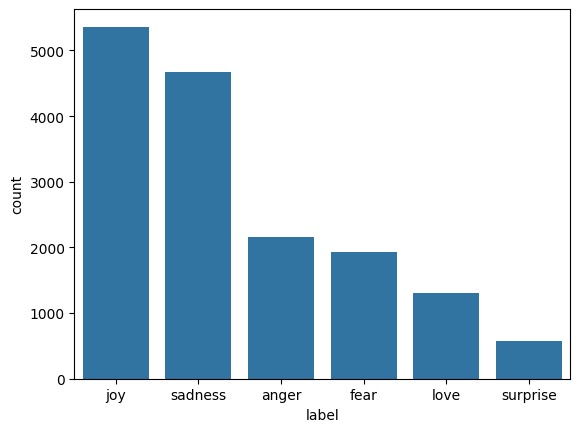

In [8]:
sns.countplot(x='label',data=df_train,order = df_train.label.value_counts().index)

**Preprocessing using NLP**

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence = pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes

print(f'Vocabulary_Size: {len(tokenizer.word_index)}')
print(f'Max_Sentance_Lenght: {padded_train_sequence.shape[1]}')

Vocabulary_Size: 15213
Max_Sentance_Lenght: 50


**Shared Training Utilities**

In [13]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
    )
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

**Simple RNN**

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.1603 - loss: 2.0670 - val_accuracy: 0.1820 - val_loss: 1.7786
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.1559 - loss: 1.8939 - val_accuracy: 0.0835 - val_loss: 1.8071
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.1379 - loss: 1.8294 - val_accuracy: 0.0905 - val_loss: 1.7934
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.1332 - loss: 1.8087 - val_accuracy: 0.2685 - val_loss: 1.7970
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1820 - loss: 1.7786
RNN Loss: 1.778639793395996
RNN Accuracy: 0.18199999630451202


**Standard LSTM**

In [18]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 111ms/step - accuracy: 0.1558 - loss: 1.7947 - val_accuracy: 0.0345 - val_loss: 1.8132
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.1369 - loss: 1.7939 - val_accuracy: 0.2860 - val_loss: 1.7449
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 101ms/step - accuracy: 0.1741 - loss: 1.7934 - val_accuracy: 0.3435 - val_loss: 1.7775
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 99ms/step - accuracy: 0.1835 - loss: 1.7876 - val_accuracy: 0.1640 - val_loss: 1.7751
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.2641 - loss: 1.6465 - val_accuracy: 0.3805 - val_loss: 1.4809
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.5125 - loss: 1.0989 - val_accuracy: 0.6650 - val_loss: 0.8866
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 95ms/step - accuracy: 0.7610 - loss: 0.6500 - val_accuracy: 0.8140 - val_loss: 0.5945
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 92ms/step - accuracy: 0.8314 - loss: 0.5020

**Standard GRU**

In [19]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.1536 - loss: 1.7970 - val_accuracy: 0.0330 - val_loss: 1.7901
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.1406 - loss: 1.7947 - val_accuracy: 0.0360 - val_loss: 1.8033
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.1612 - loss: 1.7947 - val_accuracy: 0.0340 - val_loss: 1.8080
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0330 - loss: 1.7901
GRU Loss: 1.7900882959365845
GRU Accuracy: 0.032999999821186066


**Ranking And Solution**

In [20]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.415092,0.882
0,RNN,1.778640,0.182
2,GRU,1.790088,0.033


**Advanced Bidirectional GRU**

In [21]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 248ms/step - accuracy: 0.5769 - loss: 1.0023 - val_accuracy: 0.8940 - val_loss: 0.3384
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 259ms/step - accuracy: 0.9239 - loss: 0.2160 - val_accuracy: 0.9205 - val_loss: 0.2034
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 213ms/step - accuracy: 0.9475 - loss: 0.1402 - val_accuracy: 0.9160 - val_loss: 0.2535
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 205ms/step - accuracy: 0.9585 - loss: 0.1068 - val_accuracy: 0.9240 - val_loss: 0.2267
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 203ms/step - accuracy: 0.9688 - loss: 0.0854 - val_accuracy: 0.9140 - val_loss: 0.3101


In [23]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9205 - loss: 0.2034
BiGRU Loss: 0.2033606618642807
BiGRU Accuracy: 0.9204999804496765


**Overall Evaluation & Bias Analysis**

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step


<Axes: >

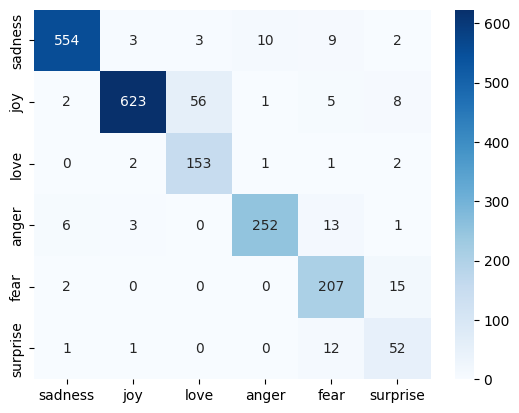

In [24]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

**Final Predictions**

In [25]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


**Save Model & Tokenizer**

In [26]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)